# Synthetic experiments in the 1 dimension setting

First, download data from pickle. 

In [9]:
import dill
kernel = "Matern52"
sweep_id_1d = "br7d1x52"
sweep_id_8d = "1ycj0lxz"
save_path_1d = f'synthetic_results/synthetic_1d_{kernel}_{sweep_id_1d}.pkl'
save_path_8d = f'synthetic_results/synthetic_8d_{kernel}_{sweep_id_8d}.pkl'

with open(save_path_1d, "rb") as f:
    metrics_per_acq_1d = dill.load(f)
with open(save_path_8d, "rb") as f:
    metrics_per_acq_8d = dill.load(f)


Here are some helper functions for computing statistics on stopping time and cost-adjusted simple regret 

In [2]:
import numpy as np
def mean_and_std(data, num_samples, axis=0):
    return np.mean(data, axis=axis), np.std(data, axis=axis) /np.sqrt(num_samples)

In [11]:
import numpy as np
import torch
import math

def return_stopping_indices_1d(
    best_obs_seed: np.ndarray,
    LogEIC_seed: np.ndarray,
    UCB_LCB_seed: np.ndarray,
    PRB_seed: np.ndarray,
    RegretGap_seed: np.ndarray,
    lmbda: float,
    max_iter: int,
    ucb_lcb_threshold: float = 0.01,
    delta: float = 0.05,
    convergence_window: int = 5,
    gss_window: int = 5,
    gss_frac: float = 0.01, 
    eta: float = 0.01,
    T_init: int = 20
) -> dict:
    """
    Compute the stopping index for various stopping rules for a single seed run.

    Parameters:
    - best_obs_seed: 1D array of best observed values per iteration.
    - LogEIC_seed: 1D array of LogEIC acquisition values.
    - UCB_LCB_seed: 1D array of (UCB - LCB) values.
    - PRB_seed: 1D array of PRB values.
    - RegretGap_seed: 1D array of Regret-Gap values.
    - lmbda: lambda value for LogEIC threshold.
    - max_iter: maximum number of iterations (iteration cutoff).
    - ucb_lcb_threshold: threshold for UCB-LCB stopping.
    - delta: parameter for PRB stopping (stop when PRB > 1 - delta).
    - convergence_window: number of consecutive iterations with no change in best observed.
    - gss_window: number of past trials to consider for GSS rule.
    - gss_frac: fraction of IQR to use as improvement threshold (e.g., 0.01 for 1%).

    Returns:
    - dict mapping stopping rule names to the stopping iteration index.
    """
    valid = {}

    # LogEIC: stop when LogEIC < log(lambda)
    valid['LogEIC'] = np.where(LogEIC_seed <= np.log(lmbda))[0]
   
    # UCB-LCB: stop when (UCB-LCB) < threshold
    valid['UCB-LCB'] = np.where(UCB_LCB_seed < ucb_lcb_threshold)[0]
    
    # PRB: stop when PRB > 1 - delta
    valid['PRB_0.1'] = np.where(PRB_seed > 1 - delta)[0]
    
    # SRGap-med: stop when regret-gap < eta * median of initial T_init gap values
    if len(RegretGap_seed) > T_init:
        median_initial = np.nanmedian(RegretGap_seed[1:T_init+1])
        # print(median_initial)
        threshold = eta * median_initial
        # print(threshold)
        valid['SRGap-med'] = np.where(RegretGap_seed < threshold)[0]
    else:
        valid['SRGap-med'] = np.array([], dtype=int)
    
    # SRGap-med: stop when LogEIC < eta * median of initial T_init LogEIC values
    if len(LogEIC_seed) > T_init:
        median_initial = np.nanmedian(LogEIC_seed[1:T_init+1])
        # print(median_initial)
        threshold = np.log(eta) + median_initial
        # print(threshold)
        valid['LogEIC-med'] = np.where(LogEIC_seed < threshold)[0]
    else:
        valid['LogEIC-med'] = np.array([], dtype=int)

    # Convergence: best observed unchanged for `convergence_window` iterations
    if len(best_obs_seed) > convergence_window:
        diffs = np.diff(best_obs_seed) == 0
        window = np.ones(convergence_window - 1, dtype=int)
        run_lengths = np.convolve(diffs.astype(int), window, mode='valid')
        conv_candidates = np.where(run_lengths == (convergence_window - 1))[0]
        if conv_candidates.size > 0:
            valid['Convergence'] = np.array([conv_candidates[0] + convergence_window - 1])
        else:
            valid['Convergence'] = np.array([], dtype=int)
    else:
        valid['Convergence'] = np.array([], dtype=int)

    # GSS: stop if improvement over past `gss_window` iters < `gss_frac` of current IQR
    valid['GSS'] = np.array([], dtype=int)
    if len(best_obs_seed) > gss_window:
        for i in range(gss_window, len(best_obs_seed)):
            past_best = best_obs_seed[i - gss_window]
            curr_best = best_obs_seed[i]
            improvement = curr_best - past_best  # assumes maximization
            # Compute IQR of best_obs_seed up to i (inclusive)
            window_vals = best_obs_seed[:i+1]
            q75, q25 = np.percentile(window_vals, [75, 25])
            iqr = q75 - q25
            if iqr <= 0:
                continue
            if improvement < gss_frac * iqr:
                valid['GSS'] = np.array([i])
                break

    # Select first valid index or fall back to max_iter - 1
    stopping_indices = {}
    for rule, inds in valid.items():
        stopping_indices[rule] = int(inds[0]) if inds.size > 0 else (max_iter - 1)
    # print("earliest EIC stopping time", stopping_indices['LogEIC'])
    return stopping_indices

In [12]:
import numpy as np
import torch
import math

def polyak_average(arr, window):
    """Compute Polyak average over a given window."""
    avg = np.full_like(arr, np.nan, dtype=float)
    cumsum = np.nancumsum(arr, dtype=float)
    for i in range(1, len(arr)):
        start = max(1, i - window + 1)
        total = cumsum[i] - (cumsum[start - 1] if start > 0 else 0.0)
        avg[i] = total / (i - start + 1)
    return avg

def return_stopping_indices_8d(
    best_obs_seed: np.ndarray,
    LogEIC_seed: np.ndarray,
    UCB_LCB_seed: np.ndarray,
    PRB_seed: np.ndarray,
    RegretGap_seed: np.ndarray,
    lmbda: float,
    max_iter: int,
    ucb_lcb_threshold: float = 0.01,
    delta: float = 0.05,
    convergence_window: int = 5,
    gss_window: int = 5,
    gss_frac: float = 0.01, 
    eta: float = 0.01,
    T_init: int = 20
) -> dict:
    """
    Compute the stopping index for various stopping rules for a single seed run.

    Parameters:
    - best_obs_seed: 1D array of best observed values per iteration.
    - LogEIC_seed: 1D array of LogEIC acquisition values.
    - UCB_LCB_seed: 1D array of (UCB - LCB) values.
    - PRB_seed: 1D array of PRB values.
    - RegretGap_seed: 1D array of Regret-Gap values.
    - lmbda: lambda value for LogEIC threshold.
    - max_iter: maximum number of iterations (iteration cutoff).
    - ucb_lcb_threshold: threshold for UCB-LCB stopping.
    - delta: parameter for PRB stopping (stop when PRB > 1 - delta).
    - convergence_window: number of consecutive iterations with no change in best observed.
    - gss_window: number of past trials to consider for GSS rule.
    - gss_frac: fraction of IQR to use as improvement threshold (e.g., 0.01 for 1%).

    Returns:
    - dict mapping stopping rule names to the stopping iteration index.
    """


    # Recover EIC
    EIC_seed = np.exp(LogEIC_seed)

    # --- Configuration ---
    window = 20
    valid = {}

    # --- Compute Polyak averages ---
    polyak_avg = {
        'LogEIC': polyak_average(EIC_seed, window),
        'UCB': polyak_average(UCB_LCB_seed, window),
        'SRGap-med': polyak_average(RegretGap_seed, window),
    }

    # --- LogEIC: stop when averaged log(EIC) < log(lambda) ---
    polyak_logEIC = np.log(polyak_avg['LogEIC'])[window:]
    valid['LogEIC'] = np.where(polyak_logEIC <= np.log(lmbda))[0] + window

    # --- UCB-LCB: stop when averaged (UCB - LCB) < threshold ---
    polyak_ucb = polyak_avg['UCB'][window:]
    valid['UCB-LCB'] = np.where(polyak_ucb <= ucb_lcb_threshold)[0] + window

    # --- SRGap-med: use Polyak-averaged RegretGap_seed ---
    if len(RegretGap_seed) > T_init:
        median_initial = np.nanmedian(RegretGap_seed[1:T_init+1])
        threshold = eta * median_initial
        polyak_srgap = polyak_avg['SRGap-med'][window:]
        valid['SRGap-med'] = np.where(polyak_srgap < threshold)[0] + window
    else:
        valid['SRGap-med'] = np.array([], dtype=int)

    # --- LogEIC-med: use Polyak-averaged LogEIC_seed ---
    if len(LogEIC_seed) > T_init:
        median_initial = np.nanmedian(EIC_seed[1:T_init+1])
        threshold = np.log(eta) + median_initial
        polyak_logeic_med = polyak_avg['LogEIC'][window:]
        valid['LogEIC-med'] = np.where(polyak_logeic_med < threshold)[0] + window
    else:
        valid['LogEIC-med'] = np.array([], dtype=int)
    
    # Convergence: best observed unchanged for `convergence_window` iterations
    if len(best_obs_seed) > convergence_window:
        diffs = np.diff(best_obs_seed) == 0
        window = np.ones(convergence_window - 1, dtype=int)
        run_lengths = np.convolve(diffs.astype(int), window, mode='valid')
        conv_candidates = np.where(run_lengths == (convergence_window - 1))[0]
        if conv_candidates.size > 0:
            valid['Convergence'] = np.array([conv_candidates[0] + convergence_window - 1])
        else:
            valid['Convergence'] = np.array([], dtype=int)
    else:
        valid['Convergence'] = np.array([], dtype=int)
    
    # GSS: stop if improvement over past `gss_window` iters < `gss_frac` of current IQR
    valid['GSS'] = np.array([], dtype=int)
    if len(best_obs_seed) > gss_window:
        for i in range(gss_window, len(best_obs_seed)):
            past_best = best_obs_seed[i - gss_window]
            curr_best = best_obs_seed[i]
            improvement = curr_best - past_best  # assumes maximization
            # Compute IQR of best_obs_seed up to i (inclusive)
            window_vals = best_obs_seed[:i+1]
            q75, q25 = np.percentile(window_vals, [75, 25])
            iqr = q75 - q25
            if iqr <= 0:
                continue
            if improvement < gss_frac * iqr:
                valid['GSS'] = np.array([i])
                break
            
    # PRB: stop when PRB > 1 - delta
    valid['PRB_0.1'] = np.where(PRB_seed > 1 - delta)[0]
    # Select first valid index or fall back to max_iter - 1
    stopping_indices = {}
    for rule, inds in valid.items():
        stopping_indices[rule] = int(inds[0]) if inds.size > 0 else (max_iter - 1)

    return stopping_indices

Setting the style and font of the plots, as well as some initial parameters.  

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import itertools
import matplotlib.ticker as ticker

# your existing lists
acquisition_functions = [
    'ThompsonSampling',
    'Stable_Gittins_Lambda_1',
    'Stable_Gittins_Lambda_01',
    'Stable_Gittins_Lambda_001',
    'LogEIWithCost', 
    'UpperConfidenceBound', 
]
acq_col_idxs = {
    'Stable_Gittins_Lambda_1':0,
    'Stable_Gittins_Lambda_01':0,
    'Stable_Gittins_Lambda_001':0,
    'LogEIWithCost':1, 
    'UpperConfidenceBound':2, 
    'ThompsonSampling':3
}

name_dict = {
    0.1: "λ = 0.1",
    0.01: "λ = 0.01",
    0.001: "λ = 0.001", 
    'Stable_Gittins_Lambda_1': "PBGI(0.1)",
    'Stable_Gittins_Lambda_01': "PBGI(0.01)",
    'Stable_Gittins_Lambda_001':"PBGI(0.001)",
    'LogEIWithCost':"LogEIPC", 
    'UpperConfidenceBound': "LCB", 
    'ThompsonSampling': "TS", 
    'PRB_0.1': "PRB",
    'LogEIC': "PBGI/LogEIPC",
    'LogEIC-med':"LogEIPC-med", 
    'UCB-LCB': "UCB-LCB",
    'Convergence': "Convergence",
    'GSS': "GSS",
    "Immediate": "Immediate",
    'SRGap-med':"SRGap-med",
    'uniform': "Uniform Cost",
    'linear': "Linear Cost",
    'periodic': "Periodic Cost"
}

lmbda_to_str = {
    0.1:'1',
    0.01:'01',
    0.001: '001'
}

color_dict = {
    'LogEIC':                  'tab:orange',
    'LogEIWithCost':           'tab:blue',
    'LogEIC-med':              'tab:blue',
    'Stable_Gittins_Lambda_1': 'tab:orange',
    'Stable_Gittins_Lambda_01':'tab:orange',
    'Stable_Gittins_Lambda_001':'tab:orange',
    'UpperConfidenceBound':    'tab:purple',
    'UCB-LCB':                 'tab:purple',
    'SRGap-med':               'tab:pink',
    'ThompsonSampling':        'tab:brown',
    'PRB_0_1':                 'tab:brown',
    'PRB_0.1':                 'tab:brown',
    'GSS':                     'tab:olive',
    'Convergence':             'tab:gray',
    'Immediate':               'tab:cyan',
    'Hindsight':               'tab:red'
}


marker_dict = {
    0.1: 'o',
    0.01: '^',
    0.001: 's'
}

lengthscales = [0.1]
cost_type = ['uniform', 'linear', 'periodic']
lambda_per_acq = [0.1, 0.01, 0.001]
lengthscales = [0.1]
# --- stopping‐rule parameters ---
delta = 0.05                        # for PRB: stop when P(success) > 1 – delta
ucb_lcb_threshold = 0.01           # for UCB–LCB: stop when (UCB – LCB) < threshold
convergence_window = 5
gss_window_1d = 5 
gss_window_8d = 20
gss_frac = 0.01             

# 'SRGap-med'
stopping_rules = [
    'LogEIC',
    'LogEIC-med',
    'SRGap-med',
    'UCB-LCB',
    'PRB_0.1',
    'GSS',
    'Convergence'
]

iteration_cutoff_1d = {}
iteration_cutoff_1d[0.1]= 100
iteration_cutoff_1d[0.01]= 100
iteration_cutoff_1d[0.001]= 100

iteration_cutoff_8d = {}
iteration_cutoff_8d[0.1]= 400
iteration_cutoff_8d[0.01]= 400
iteration_cutoff_8d[0.001]= 400

Plots: only showing cost-adjusted regret 


In [25]:
sns.set_style('whitegrid', {
    'grid.linestyle': '--',
    'grid.alpha': 0.4
})

plt.style.use('seaborn-v0_8-bright')
#plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams["font.sans-serif"] = "Liberation Sans"

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    # 'xtick.rotation': 45,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.autolayout': False,  # we'll call tight_layout() explicitly
})

x_labels ['PBGI', 'LogEIPC', 'LCB', 'TS']
x_labels ['PBGI', 'LogEIPC', 'LCB', 'TS']
Immediate (λ = 0.001): mean = 0.6942, 2*stderr = 0.1628 (range: [0.5314, 0.8570])
x_labels ['PBGI', 'LogEIPC', 'LCB', 'TS']
limits: 0, 7.3555065821828105
x_labels 8d ['PBGI', 'LogEIPC', 'LCB', 'TS']
limits: 0, 7.358177217557145
x_labels 8d ['PBGI', 'LogEIPC', 'LCB', 'TS']
limits: 0, 7.3889073617297845
x_labels 8d ['PBGI', 'LogEIPC', 'LCB', 'TS']


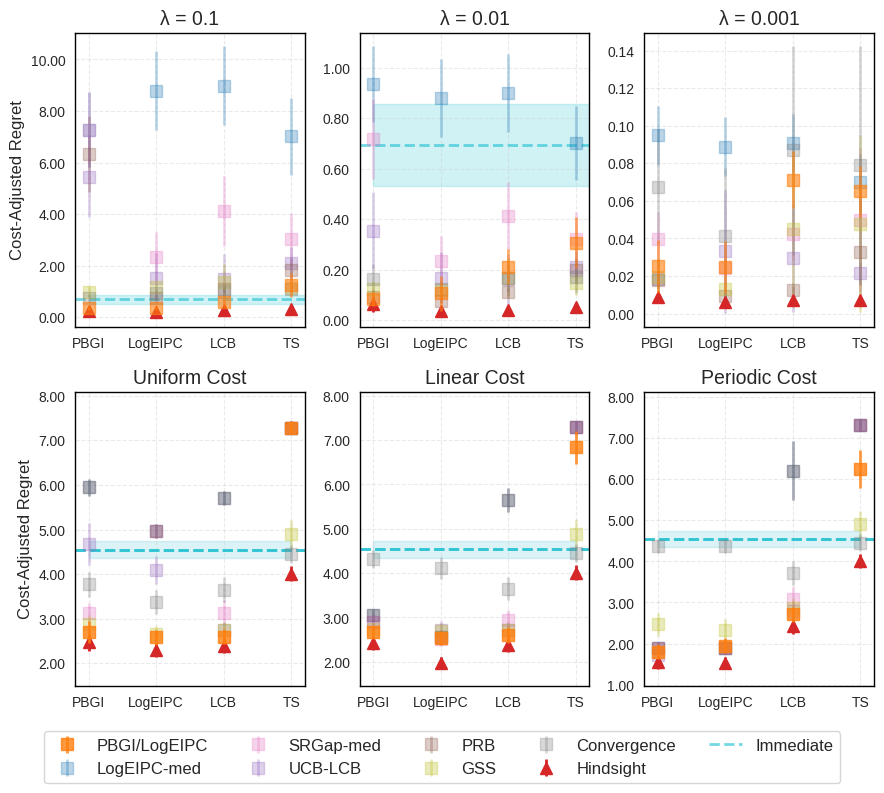

In [ ]:
from matplotlib.ticker import ScalarFormatter
enable_immediate = True
if (enable_immediate):
    stopping_rules.append('Immediate')

l = 0.1

def style_spines(ax, color='black', linewidth=1):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(linewidth)


# build list of column settings
cost_type = ['uniform', 'linear', 'periodic']
col_settings = list(itertools.product(cost_type))
n_cols = len(col_settings)
n_rows = 2

cost_type_1d = 'linear'
lambda_8d = 0.01

fig, axes = plt.subplots(
    n_rows, n_cols, 
    figsize=(3 * n_cols, 4 * n_rows),   # adjust per‐subplot size
    sharex=False, sharey=False
)

#axes = axes.T
# ensure axes is always shape (n_rows, n_cols)
axes = np.array(axes)

    
# 1D plots
cost = cost_type_1d
for col_idx, lmbda in enumerate(lambda_per_acq):
    x_labels = [""] * (len(acquisition_functions)-2)
    for a in acquisition_functions: 
        if a.split("_")[0] == "Stable" and a.split("_")[-1] != lmbda_to_str[lmbda]:
            continue
        ax = axes[0, col_idx] 
        acq_function_idx = acq_col_idxs[a]
        x_labels[acq_function_idx] = name_dict[a]

        metric_keys = [
            "cumulative cost",
            "best observed",
            "regret", 
            "StablePBGI(0.1) acq",
            "StablePBGI(0.01) acq",
            "StablePBGI(0.001) acq",
            "LogEIC acq", 
            "UCB-LCB acq", 
            "Regret-Gap acq", 
            "PRB_0.1"
        ]
        
        regret = np.array(metrics_per_acq_1d[(a, l, cost)]['regret'])[:, :iteration_cutoff_1d[lmbda]]
        cumulative_cost = np.array(metrics_per_acq_1d[(a, l, cost)]["cumulative cost"])[:, :iteration_cutoff_1d[lmbda]]
        LogEIC_acq = np.array(metrics_per_acq_1d[(a, l, cost)]["LogEIC acq"])[:, :iteration_cutoff_1d[lmbda]]
        UCB_LCB_acq = np.array(metrics_per_acq_1d[(a, l, cost)]["UCB-LCB acq"])[:, :iteration_cutoff_1d[lmbda]]
        PRB_0_1_acq = np.array(metrics_per_acq_1d[(a, l, cost)]["PRB_0.1"])[:, :iteration_cutoff_1d[lmbda]]
        RegretGap_acq = np.array(metrics_per_acq_1d[(a, l, cost)]["Regret-Gap acq"])[:, :iteration_cutoff_1d[lmbda]] 
        best_observed = np.array(metrics_per_acq_1d[(a, l, cost)]["best observed"])[:, :iteration_cutoff_1d[lmbda]]

        # Compute cost-adjusted regret curve
        cost_adjusted_regret = regret + lmbda * cumulative_cost

        #Compute stopping point, which is the first time acq < best observed 
        stopping_times = {}
        stopping_cost_adjusted_regrets = {}
        for stopping_rule in stopping_rules: 
            stopping_cost_adjusted_regrets[stopping_rule] = []
            stopping_times[stopping_rule] = []
        
        hindsight_best_times = []
        hindsight_best_regrets = []

        n_seeds = regret.shape[0]

        for seed_idx in range(n_seeds):
            best_obs_seed = best_observed[seed_idx]
            stopping_indices = return_stopping_indices_1d(
                best_obs_seed=best_obs_seed,
                LogEIC_seed=LogEIC_acq[seed_idx],
                UCB_LCB_seed=UCB_LCB_acq[seed_idx],
                PRB_seed=PRB_0_1_acq[seed_idx],
                RegretGap_seed=RegretGap_acq[seed_idx],
                lmbda=lmbda,
                max_iter=iteration_cutoff_1d[lmbda],
                ucb_lcb_threshold=ucb_lcb_threshold,
                delta=delta,
                convergence_window=convergence_window,
                gss_window=gss_window_1d,
                gss_frac=gss_frac
            )

            for stopping_rule in stopping_rules:
                if stopping_rule == 'Immediate':
                    i_stop = 0
                    stopping_times[stopping_rule].append(0)
                else:
                    i_stop = stopping_indices[stopping_rule]
                    stopping_times[stopping_rule].append(stopping_indices[stopping_rule])
                cost_adj_regret_at_stop = cost_adjusted_regret[seed_idx, i_stop]
                stopping_cost_adjusted_regrets[stopping_rule].append(cost_adj_regret_at_stop)


            i_best = np.argmin(cost_adjusted_regret[seed_idx])
            hindsight_best_times.append(i_best)
            hindsight_best_regrets.append(cost_adjusted_regret[seed_idx, i_best])
    
        # Convert to arrays
        for stopping_rule in stopping_rules:
            stopping_times[stopping_rule] = np.array(stopping_times[stopping_rule])
            stopping_cost_adjusted_regrets[stopping_rule] = np.array(stopping_cost_adjusted_regrets[stopping_rule])
    
        # Plot cost adjusted simple regret of different stopping rules, on the same axis 
        for i, rule in enumerate(stopping_rules):
            if rule == 'Immediate':
                continue  # Skip Immediate here, will handle it outside the acquisition function loop
            
            mt,ms = mean_and_std(stopping_times[rule], n_seeds) 
            et,es = mean_and_std(stopping_cost_adjusted_regrets[rule], n_seeds)
            
            if rule == 'LogEIC':
                zorder=3; alpha = 0.6
            else:
                zorder=2; alpha = 0.3
            
            ax.errorbar(acq_function_idx,et,yerr=2*es,
                        fmt='s', 
                        markersize=8,
                        linewidth=2,
                        color=color_dict[rule], 
                        capsize=0, 
                        label=name_dict[rule], 
                        zorder=zorder, 
                        alpha=alpha)
        
        mean_hindsight_time, stderr_hindsight_time = mean_and_std(hindsight_best_times, n_seeds)
        mean_hindsight_regret, stderr_hindsight_regret = mean_and_std(hindsight_best_regrets, n_seeds) 
        
        ax.errorbar(acq_function_idx, 
                    mean_hindsight_regret,
                    yerr=2*stderr_hindsight_regret,
                    fmt='^', 
                    linewidth=2,
                    markersize=8, zorder=2, color=color_dict['Hindsight'], capsize=0, label='Hindsight')
    
    # Handle Immediate stopping rule once per subplot (outside acquisition function loop)
    ax = axes[0, col_idx]  # Ensure ax is set for this subplot
    if 'Immediate' in stopping_rules:
        # Use LogEIWithCost as representative acquisition function for computing Immediate
        a_representative = 'LogEIWithCost'
        regret_imm = np.array(metrics_per_acq_1d[(a_representative, l, cost)]['regret'])[:, :iteration_cutoff_1d[lmbda]]
        cumulative_cost_imm = np.array(metrics_per_acq_1d[(a_representative, l, cost)]["cumulative cost"])[:, :iteration_cutoff_1d[lmbda]]
        cost_adjusted_regret_imm = regret_imm + lmbda * cumulative_cost_imm
        
        # Immediate always stops at iteration 0
        immediate_regrets = cost_adjusted_regret_imm[:, 0]
        et_imm, es_imm = mean_and_std(immediate_regrets, len(immediate_regrets))
        
        if col_idx == 2:  # lambda=0.001
            # Print instead of plotting (showing mean ± 2*stderr like the error bars in plots)
            print(f"Immediate ({name_dict[lmbda]}): mean = {et_imm:.4f}, 2*stderr = {2*es_imm:.4f} (range: [{et_imm-2*es_imm:.4f}, {et_imm+2*es_imm:.4f}])")
        else:
            # Plot horizontal line across all acquisition functions
            ax.axhline(y=et_imm, xmin=0, xmax=1, 
                        color='tab:cyan', linestyle='--', linewidth=2, alpha=0.6, zorder=1)
                        
            # Add shaded error region (using x-range of acquisition functions: 0 to len(acquisition_functions)-2)
            num_acq = len(acquisition_functions) - 2
            ax.fill_between([0, num_acq], 
                            [et_imm - 2*es_imm, et_imm - 2*es_imm],
                            [et_imm + 2*es_imm, et_imm + 2*es_imm],
                            color='tab:cyan', alpha=0.2, zorder=0)
            
    # Add label only once
    ax.plot([], [], color='tab:cyan', linestyle='--', linewidth=2, 
            alpha=0.6, label='Immediate')
    ax.set_title(name_dict[lmbda], fontsize=14)
    
    # Let matplotlib auto-scale the y-axis
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    # ax.set_xlim(-0.9, n_rows - 0.1)
    x_labels = [name.split('(')[0] for name in x_labels]
    print("x_labels", x_labels)
    ax.set_xlim(-0.2, len(x_labels) - 0.8)
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels)
    # ax.set_xticks([x + 0.5 for x in range(-1, n_rows)], minor=True)
    ax.grid(which='major', linestyle='--', alpha=0.4)
    ax.grid(which='minor', visible=False)
    ax.set_ylabel("Cost-Adjusted Regret" if col_idx == 0 else "")
    
    style_spines(ax)

# 8D plots
lmbda = lambda_8d
for col_idx, cost in enumerate(cost_type):
    max_y = 0
    min_y = 100
    x_labels = [""] * (len(acquisition_functions)-2)
    for a in acquisition_functions: # col_idx, a in enumerate(acquisition_functions):
        # print(a.split("_")[-1])
        if a.split("_")[0] == "Stable" and a.split("_")[-1] != lmbda_to_str[lmbda]:
            continue

        ax = axes[1, col_idx] # acq_col_idxs[a]]
        acq_function_idx = acq_col_idxs[a]
        x_labels[acq_function_idx] = name_dict[a]

        metric_keys = [
            "cumulative cost",
            "best observed",
            "regret", 
            "StablePBGI(0.1) acq",
            "StablePBGI(0.01) acq",
            "StablePBGI(0.001) acq",
            "LogEIC acq", 
            "UCB-LCB acq", 
            "Regret-Gap acq", 
            "PRB_0.1"
        ]

        # print(np.array(metrics_per_acq[(a, l, cost)]))
        regret = np.array(metrics_per_acq_8d[(a, l, cost)]['regret'])[:, :iteration_cutoff_8d[lmbda]]
        cumulative_cost = np.array(metrics_per_acq_8d[(a, l, cost)]["cumulative cost"])[:, :iteration_cutoff_8d[lmbda]]
        LogEIC_acq = np.array(metrics_per_acq_8d[(a, l, cost)]["LogEIC acq"])[:, :iteration_cutoff_8d[lmbda]]
        UCB_LCB_acq = np.array(metrics_per_acq_8d[(a, l, cost)]["UCB-LCB acq"])[:, :iteration_cutoff_8d[lmbda]]
        PRB_0_1_acq = np.array(metrics_per_acq_8d[(a, l, cost)]["PRB_0.1"])[:, :iteration_cutoff_8d[lmbda]]
        RegretGap_acq = np.array(metrics_per_acq_8d[(a, l, cost)]["Regret-Gap acq"])[:, :iteration_cutoff_8d[lmbda]] 
        # current_best = np.array(current_best_per_acq[(a, l)])[:, :iteration_cutoff]
        best_observed = np.array(metrics_per_acq_8d[(a, l, cost)]["best observed"])[:, :iteration_cutoff_8d[lmbda]]

        # Compute cost-adjusted regret curve
        cost_adjusted_regret = regret + lmbda * cumulative_cost

        # === 1. Compute stopping point, which is the first time acq < best observed 
        stopping_times = {}
        stopping_cost_adjusted_regrets = {}
        for stopping_rule in stopping_rules: 
            stopping_cost_adjusted_regrets[stopping_rule] = []
            stopping_times[stopping_rule] = []
        
        hindsight_best_times = []
        hindsight_best_regrets = []

        n_seeds = regret.shape[0]

        for seed_idx in range(n_seeds):
            best_obs_seed = best_observed[seed_idx]
            stopping_indices = return_stopping_indices_8d(
                best_obs_seed=best_obs_seed,
                LogEIC_seed=LogEIC_acq[seed_idx],
                UCB_LCB_seed=UCB_LCB_acq[seed_idx],
                PRB_seed=PRB_0_1_acq[seed_idx],
                RegretGap_seed=RegretGap_acq[seed_idx],
                lmbda=lmbda,
                max_iter=iteration_cutoff_8d[lmbda],
                ucb_lcb_threshold=ucb_lcb_threshold,
                delta=delta,
                convergence_window=convergence_window,
                gss_window=gss_window_8d,
                gss_frac=gss_frac
            )

            # Only include if stopping condition met
            for stopping_rule in stopping_rules:
                if stopping_rule == 'Immediate':
                    i_stop = 0
                    stopping_times[stopping_rule].append(0)
                else:
                    i_stop = stopping_indices[stopping_rule]
                    stopping_times[stopping_rule].append(stopping_indices[stopping_rule])
                cost_adj_regret_at_stop = cost_adjusted_regret[seed_idx, i_stop]
                stopping_cost_adjusted_regrets[stopping_rule].append(cost_adj_regret_at_stop)

            i_best = np.argmin(cost_adjusted_regret[seed_idx])
            hindsight_best_times.append(i_best)
            hindsight_best_regrets.append(cost_adjusted_regret[seed_idx, i_best])
    
        # Convert to arrays
        for stopping_rule in stopping_rules:
            stopping_times[stopping_rule] = np.array(stopping_times[stopping_rule])
            stopping_cost_adjusted_regrets[stopping_rule] = np.array(stopping_cost_adjusted_regrets[stopping_rule])

        # Plot cost adjusted simple regret of different stopping rules, on the same axis
        for i, rule in enumerate(stopping_rules):
            mt,ms = mean_and_std(stopping_times[rule], n_seeds) 
            et,es = mean_and_std(stopping_cost_adjusted_regrets[rule], n_seeds)
            max_y = max(max_y, et + es)
            min_y = min(min_y, et - es)
            if rule == 'LogEIC':
                zorder=3
                alpha = 0.8
            else:
                zorder=2
                alpha = 0.3
            if rule == 'Immediate':
                continue 
                
            else:

                ax.errorbar(acq_function_idx, et, yerr=2*es,markersize=8,
                            linewidth=2,
                            fmt='s', 
                            color=color_dict[rule], 
                            capsize=0, 
                            label=name_dict[rule], 
                            zorder=zorder, 
                            alpha=alpha)
        
        mean_hindsight_time, stderr_hindsight_time = mean_and_std(hindsight_best_times, n_seeds)
        mean_hindsight_regret, stderr_hindsight_regret = mean_and_std(hindsight_best_regrets, n_seeds) 
        
        ax.errorbar(acq_function_idx,mean_hindsight_regret,yerr=2*stderr_hindsight_regret,
                    fmt='^', 
                    markersize=8, 
                    linewidth=2,
                    color=color_dict['Hindsight'], 
                    capsize=0, 
                    label='Hindsight')
                    
        mean_immediate,stderr_immediate = mean_and_std(stopping_cost_adjusted_regrets["Immediate"], n_seeds) 
        if (enable_immediate):
            # Plot Immediate as horizontal line with shaded error bars
            ax.axhline(y=mean_immediate, xmin=0, xmax=1, 
                    color='tab:cyan', linestyle='--', linewidth=2, alpha=0.4, zorder=1)
    
            # Add shaded error region
            ax.fill_between([0, n_cols], 
                                [mean_immediate - 2*stderr_immediate, mean_immediate - 2*stderr_immediate],
                                [mean_immediate + 2*stderr_immediate, mean_immediate + 2*stderr_immediate],
                                color='tab:cyan', alpha=0.04, zorder=0) 
        
    print(f"limits: {0}, {max_y}")

    # Add label only once
    ax.plot([], [], color='tab:cyan', linestyle='--', linewidth=2, 
            alpha=0.6, label='Immediate')

    ax.set_title(name_dict[cost], fontsize=14)

    ax.set_ylim(min_y*0.6, max_y*1.1)
    plain_formatter = ScalarFormatter()
    plain_formatter.set_scientific(False)
    plain_formatter.set_useOffset(False)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    # ax.set_xlim(-0.9, n_cols - 0.1)
    x_labels = [name.split('(')[0] for name in x_labels]
    print("x_labels 8d", x_labels)
    ax.set_xlim(-0.2, len(x_labels) - 0.8)
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels)
    # ax.set_xticks([x + 0.5 for x in range(-1, n_cols)], minor=True)
    ax.grid(which='major', linestyle='--', alpha=0.4)
    ax.grid(which='minor', visible=False)
    ax.set_ylabel("Cost-Adjusted Regret" if col_idx == 0 else "")
    
    style_spines(ax)



# one legend for entire figure
handles, labels = axes[1,0].get_legend_handles_labels()
legend_hls = dict(zip(labels, handles))
if 'Immediate' in legend_hls:
    immediate_handle = legend_hls.pop('Immediate')
    legend_hls['Immediate'] = immediate_handle
fig.legend(legend_hls.values(), legend_hls.keys(), # handles, labels,
            loc='lower center',
            bbox_to_anchor=(0.5, 0),
            ncol=5,
            fontsize=12)

plt.tight_layout(rect=[0, 0.08, 1, 1.0])
plt.savefig(f'../plots/BarPlot_{kernel}.pdf', bbox_inches='tight')
plt.show()